In [1]:
# ============================================
# CELL 1 — Summary Statistics
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Excel/Cleaned_Mesy_HR_Dataset.csv")

# 1. Basic shape
print("=== SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Column names and types
print("\n=== COLUMN INFO ===")
print(df.info())

# 3. Statistical summary
print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

# 4. Categorical columns summary
print("\n=== CATEGORICAL SUMMARY ===")
cat_cols = ['Gender', 'Department', 'City', 'Education', 'Remote_Work']
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


=== SHAPE ===
Rows: 200, Columns: 14

=== COLUMN INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        200 non-null    str    
 1   First_Name         200 non-null    str    
 2   Last_Name          200 non-null    str    
 3   Age                200 non-null    float64
 4   Gender             200 non-null    str    
 5   Department         200 non-null    str    
 6   City               200 non-null    str    
 7   Salary             200 non-null    float64
 8   Experience_Years   200 non-null    float64
 9   Performance_Score  200 non-null    float64
 10  Education          200 non-null    str    
 11  Join_Date          200 non-null    str    
 12  Remote_Work        200 non-null    str    
 13  Bonus              200 non-null    float64
dtypes: float64(5), str(9)
memory usage: 22.0 KB
None

=== STATISTICAL SUMMARY =

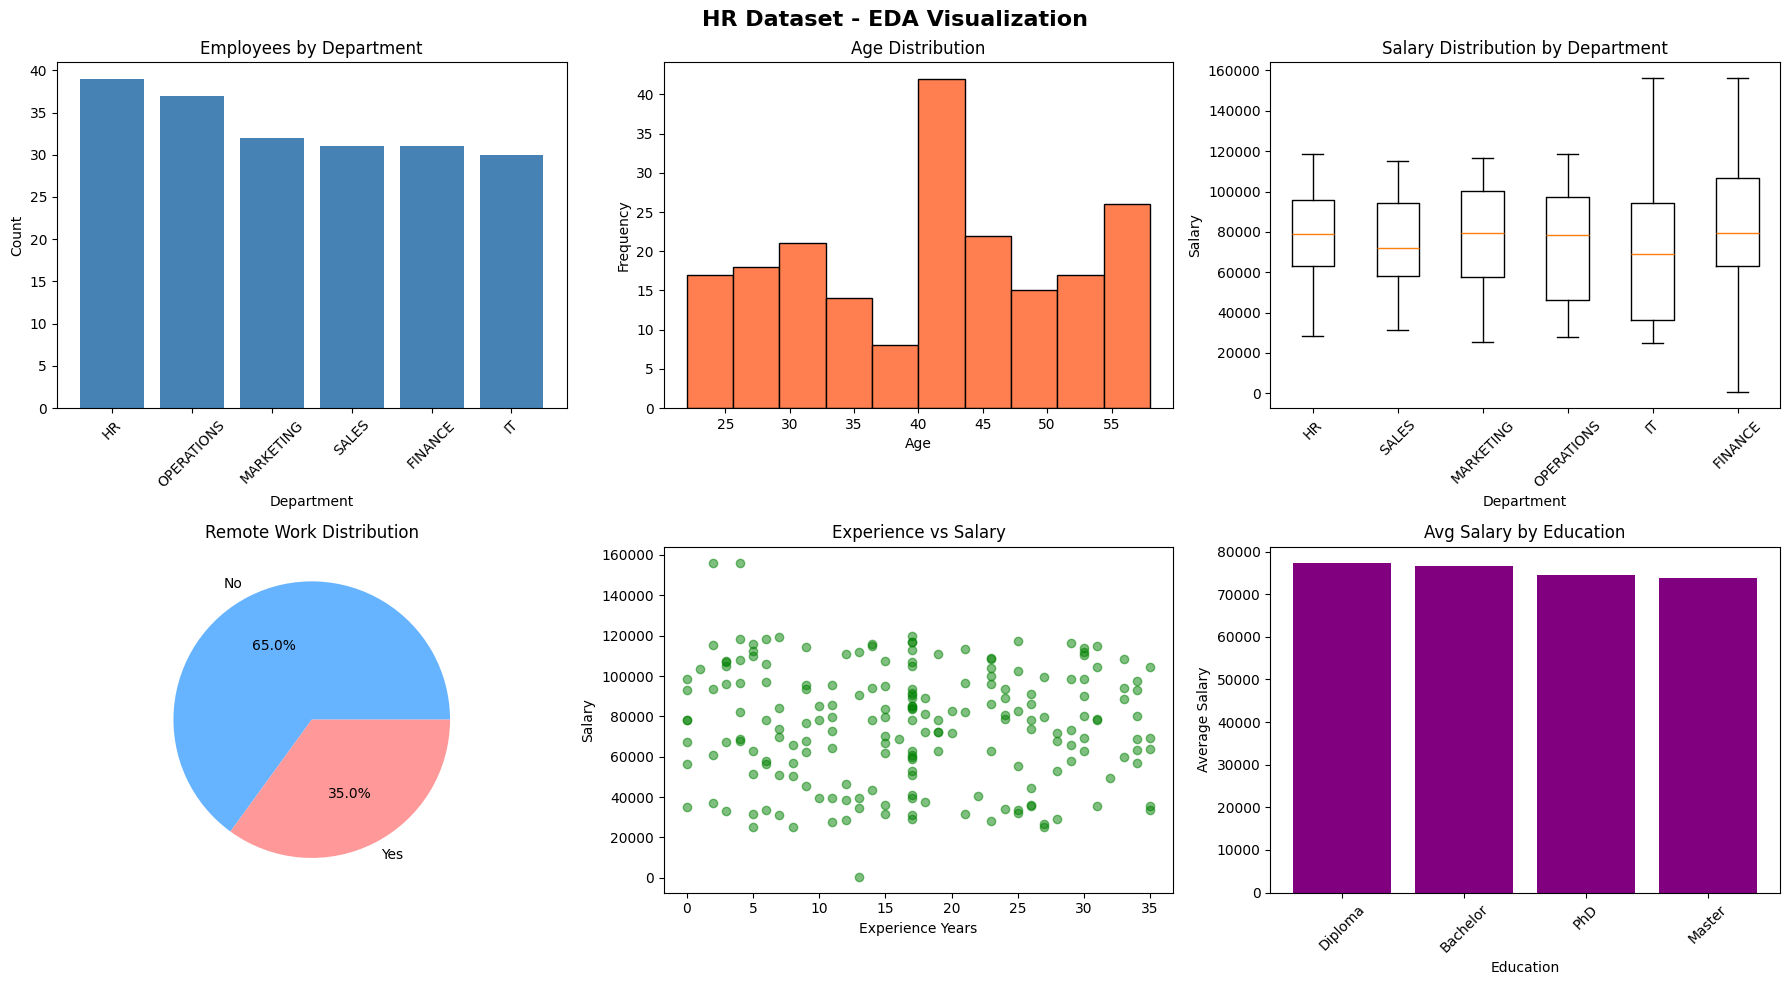

In [2]:
# ============================================
# CELL 2 — Data Visualization
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HR Dataset - EDA Visualization', fontsize=16, fontweight='bold')

# --- Chart 1: Bar Chart — Employee count by Department ---
dept_counts = df['Department'].value_counts()
axes[0, 0].bar(dept_counts.index, dept_counts.values, color='steelblue')
axes[0, 0].set_title('Employees by Department')
axes[0, 0].set_xlabel('Department')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Chart 2: Histogram — Age distribution ---
axes[0, 1].hist(df['Age'], bins=10, color='coral', edgecolor='black')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# --- Chart 3: Box Plot — Salary by Department ---
dept_salary = [df[df['Department'] == dept]['Salary'].values 
               for dept in df['Department'].unique()]
axes[0, 2].boxplot(dept_salary, tick_labels=df['Department'].unique())
axes[0, 2].set_title('Salary Distribution by Department')
axes[0, 2].set_xlabel('Department')
axes[0, 2].set_ylabel('Salary')
axes[0, 2].tick_params(axis='x', rotation=45)

# --- Chart 4: Pie Chart — Remote Work ---
remote_counts = df['Remote_Work'].value_counts()
axes[1, 0].pie(remote_counts.values, labels=remote_counts.index,
               autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'])
axes[1, 0].set_title('Remote Work Distribution')

# --- Chart 5: Scatter Plot — Experience vs Salary ---
axes[1, 1].scatter(df['Experience_Years'], df['Salary'], 
                   alpha=0.5, color='green')
axes[1, 1].set_title('Experience vs Salary')
axes[1, 1].set_xlabel('Experience Years')
axes[1, 1].set_ylabel('Salary')

# --- Chart 6: Bar Chart — Average Salary by Education ---
edu_salary = df.groupby('Education')['Salary'].mean().sort_values(ascending=False)
axes[1, 2].bar(edu_salary.index, edu_salary.values, color='purple')
axes[1, 2].set_title('Avg Salary by Education')
axes[1, 2].set_xlabel('Education')
axes[1, 2].set_ylabel('Average Salary')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



=== CORRELATION MATRIX ===
                    Age  Salary  Experience_Years  Performance_Score  Bonus
Age                1.00   -0.03             -0.01               0.09   0.00
Salary            -0.03    1.00             -0.04              -0.02   0.06
Experience_Years  -0.01   -0.04              1.00              -0.04  -0.06
Performance_Score  0.09   -0.02             -0.04               1.00  -0.04
Bonus              0.00    0.06             -0.06              -0.04   1.00


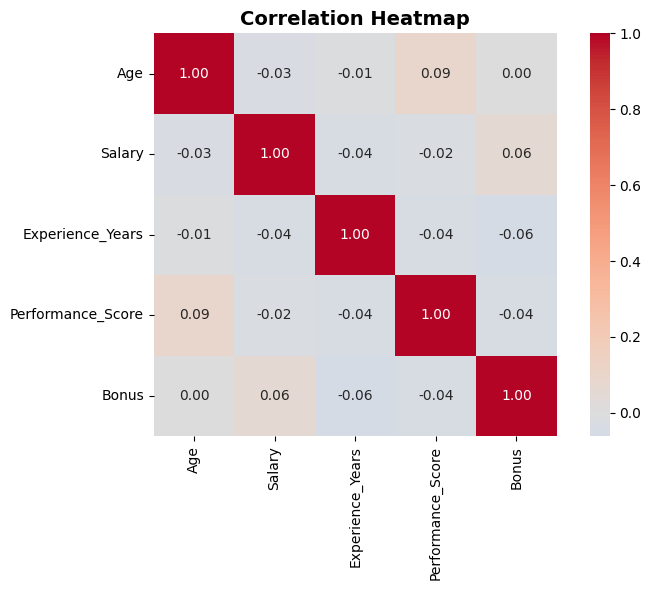


=== KEY INSIGHTS ===

=== AVG SALARY BY GENDER ===
Gender
Female    73174.69
Male      79007.08
Name: Salary, dtype: float64

=== AVG PERFORMANCE BY DEPARTMENT ===
Department
FINANCE       6.11
SALES         6.08
OPERATIONS    5.61
MARKETING     5.47
HR            5.09
IT            4.93
Name: Performance_Score, dtype: float64


In [3]:
# ============================================
# CELL 3 — Identifying Patterns & Correlations
# ============================================

# 1. Correlation Matrix (numbers)
print("=== CORRELATION MATRIX ===")
numeric_cols = ['Age', 'Salary', 'Experience_Years', 'Performance_Score', 'Bonus']
corr_matrix = df[numeric_cols].corr()
print(corr_matrix.round(2))

# 2. Heatmap (visual)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,        # show numbers
            fmt='.2f',         # 2 decimal places
            cmap='coolwarm',   # red=positive, blue=negative
            center=0,
            square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('HR_Correlation_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Key insights from correlation
print("\n=== KEY INSIGHTS ===")
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]
        val = corr_matrix.loc[col1, col2]

        if abs(val) >= 0.3:
            direction = "positive" if val > 0 else "negative"
            strength = "strong" if abs(val) >= 0.6 else "moderate"

            print(f"{col1} vs {col2}: {strength} {direction} ({val:.2f})")

# 4. Salary by Gender
print("\n=== AVG SALARY BY GENDER ===")
print(df.groupby('Gender')['Salary'].mean().round(2))

# 5. Performance by Department
print("\n=== AVG PERFORMANCE BY DEPARTMENT ===")
print(df.groupby('Department')['Performance_Score'].mean().round(2).sort_values(ascending=False))


In [4]:
# ============================================
# CELL 4 — Merging & Joining Datasets
# ============================================

# First — create 2 separate tables to merge!
# (like real world — HR system + Salary system!)

# Table 1 — Employee basic info
df_employees = df[['Employee_ID', 'First_Name', 'Last_Name', 
                   'Age', 'Gender', 'Department', 'City']].copy()

# Table 2 — Employee salary info
df_salary = df[['Employee_ID', 'Salary', 
                'Bonus', 'Performance_Score']].copy()

# Table 3 — Some employees ONLY (to demo LEFT JOIN!)
df_salary_partial = df_salary.head(150).copy()  # only 150 out of 200!

print("=== TABLE SIZES ===")
print(f"Employees table : {df_employees.shape}")   # 200 rows
print(f"Salary table    : {df_salary.shape}")       # 200 rows
print(f"Partial salary  : {df_salary_partial.shape}") # 150 rows

print("\n=== EMPLOYEES TABLE (first 3) ===")
print(df_employees.head(3))

print("\n=== SALARY TABLE (first 3) ===")
print(df_salary.head(3))

# ---- INNER JOIN ----
inner = pd.merge(df_employees, df_salary_partial, 
                 on='Employee_ID', how='inner')
print(f"\n=== INNER JOIN ===")
print(f"Result: {inner.shape}")  # only matching rows → 150!
print("Only employees WHO HAVE salary data!")
print(inner.head(3))

# ---- LEFT JOIN ----
left = pd.merge(df_employees, df_salary_partial, 
                on='Employee_ID', how='left')
print(f"\n=== LEFT JOIN ===")
print(f"Result: {left.shape}")  # all 200 employees!
print(f"Missing salary rows: {left['Salary'].isnull().sum()}")  # 50 NaN!
print("ALL employees kept, NaN where no salary!")
print(left.tail(3))  # last rows will have NaN salary

# ---- OUTER JOIN ----
outer = pd.merge(df_employees, df_salary_partial, 
                 on='Employee_ID', how='outer')
print(f"\n=== OUTER JOIN ===")
print(f"Result: {outer.shape}")  # 200 (everything!)
print("EVERYTHING from both tables!")


=== TABLE SIZES ===
Employees table : (200, 7)
Salary table    : (200, 4)
Partial salary  : (150, 4)

=== EMPLOYEES TABLE (first 3) ===
  Employee_ID First_Name Last_Name   Age  Gender Department       City
0     EMP1000       Sara    Sharma  41.0  Female         HR       PUNE
1     EMP1001      Priya    Sharma  27.0    Male      SALES  HYDERABAD
2     EMP1002     Nikhil     Singh  49.0  Female         HR  BANGALORE

=== SALARY TABLE (first 3) ===
  Employee_ID    Salary     Bonus  Performance_Score
0     EMP1000  89286.45  10177.61                5.5
1     EMP1001  93021.86  16379.18                4.8
2     EMP1002  33810.86  16335.44                4.2

=== INNER JOIN ===
Result: (150, 10)
Only employees WHO HAVE salary data!
  Employee_ID First_Name Last_Name   Age  Gender Department       City  \
0     EMP1000       Sara    Sharma  41.0  Female         HR       PUNE   
1     EMP1001      Priya    Sharma  27.0    Male      SALES  HYDERABAD   
2     EMP1002     Nikhil     Singh  49.

In [5]:
# ============================================
# CELL 5 — Data Aggregation
# ============================================

print("=== 1. AVG SALARY BY DEPARTMENT ===")
dept_salary = df.groupby('Department')['Salary'].mean().round(2).sort_values(ascending=False)
print(dept_salary)

print("\n=== 2. TOTAL BONUS BY CITY ===")
city_bonus = df.groupby('City')['Bonus'].sum().round(2).sort_values(ascending=False)
print(city_bonus)

print("\n=== 3. EMPLOYEE COUNT BY EDUCATION ===")
edu_count = df.groupby('Education')['Employee_ID'].count()
print(edu_count)

print("\n=== 4. MULTIPLE AGGREGATIONS AT ONCE ===")
dept_stats = df.groupby('Department').agg(
    Total_Employees  = ('Employee_ID', 'count'),
    Avg_Salary       = ('Salary', 'mean'),
    Max_Salary       = ('Salary', 'max'),
    Avg_Performance  = ('Performance_Score', 'mean'),
    Avg_Experience   = ('Experience_Years', 'mean')
).round(2)
print(dept_stats)

print("\n=== 5. REMOTE WORK SALARY COMPARISON ===")
remote_salary = df.groupby('Remote_Work')['Salary'].agg(['mean','min','max']).round(2)
print(remote_salary)

print("\n=== 6. TOP 5 HIGHEST PAID EMPLOYEES ===")
top5 = df[['First_Name','Last_Name','Department','Salary']].sort_values('Salary', ascending=False).head(5)
print(top5)

print("\n=== 7. PIVOT TABLE — Avg Salary by Dept & Gender ===")
pivot = df.pivot_table(values='Salary', 
                       index='Department', 
                       columns='Gender', 
                       aggfunc='mean').round(2)
print(pivot)

=== 1. AVG SALARY BY DEPARTMENT ===
Department
FINANCE       81268.07
HR            78713.07
MARKETING     76850.31
SALES         74244.07
OPERATIONS    73226.59
IT            68269.40
Name: Salary, dtype: float64

=== 2. TOTAL BONUS BY CITY ===
City
BANGALORE    450037.95
HYDERABAD    407600.00
DELHI        380918.90
PUNE         295590.37
MUMBAI       278006.98
CHENNAI      271724.25
Name: Bonus, dtype: float64

=== 3. EMPLOYEE COUNT BY EDUCATION ===
Education
Bachelor    49
Diploma     49
Master      55
PhD         47
Name: Employee_ID, dtype: int64

=== 4. MULTIPLE AGGREGATIONS AT ONCE ===
            Total_Employees  Avg_Salary  Max_Salary  Avg_Performance  \
Department                                                             
FINANCE                  31    81268.07   156248.14             6.11   
HR                       39    78713.07   118473.92             5.09   
IT                       30    68269.40   156248.14             4.93   
MARKETING                32    76850.31

In [6]:
# ============================================
# CELL 6 — Handling Different Data Formats
# ============================================
import sqlite3
import os

# ==========================================
# PART 1 — CSV
# ==========================================
print("=== CSV FORMAT ===")

# Write CSV
df.to_csv("HR_Export.csv", index=False)
print(" Saved to CSV!")

# Read CSV back
df_csv = pd.read_csv("HR_Export.csv")
print(f"Read back: {df_csv.shape}")
print(df_csv[['Employee_ID','First_Name','Salary']].head(3))


# ==========================================
# PART 2 — JSON
# ==========================================
print("\n=== JSON FORMAT ===")

# Write JSON
df.to_json("HR_Export.json", orient='records', indent=2)
print(" Saved to JSON!")

# Read JSON back
df_json = pd.read_json("HR_Export.json")
print(f"Read back: {df_json.shape}")
print(df_json[['Employee_ID','First_Name','Salary']].head(3))

# Show what JSON looks like
import json
with open("HR_Export.json", 'r') as f:
    sample = json.load(f)
print("\nJSON structure (first record):")
print(json.dumps(sample[0], indent=2))


# ==========================================
# PART 3 — SQL (SQLite)
# ==========================================
print("\n=== SQL FORMAT ===")

# Create database and save
conn = sqlite3.connect("HR_Database.db")
df.to_sql("employees", conn, if_exists='replace', index=False)
print(" Saved to SQL database!")

# Query 1 — Basic SELECT
print("\n--- Query 1: All IT employees ---")
q1 = pd.read_sql("SELECT Employee_ID, First_Name, Department, Salary FROM employees WHERE Department = 'IT' LIMIT 5", conn)
print(q1)

# Query 2 — Aggregation in SQL
print("\n--- Query 2: Avg Salary by Department ---")
q2 = pd.read_sql("""
    SELECT Department, 
           COUNT(*) as Total,
           ROUND(AVG(Salary), 2) as Avg_Salary
    FROM employees 
    GROUP BY Department
    ORDER BY Avg_Salary DESC
""", conn)
print(q2)

# Query 3 — Filter + Sort
print("\n--- Query 3: Top 5 earners ---")
q3 = pd.read_sql("""
    SELECT First_Name, Last_Name, Department, Salary
    FROM employees
    ORDER BY Salary DESC
    LIMIT 5
""", conn)
print(q3)

conn.close()
print("\n Database connection closed!")

# ==========================================
# COMPARISON SUMMARY
# ==========================================
print("\n=== FILE SIZES ===")
for file in ["HR_Export.csv", "HR_Export.json", "HR_Database.db"]:
    size = os.path.getsize(file)
    print(f"{file:25} → {size:,} bytes  ({size//1024} KB)")


=== CSV FORMAT ===
 Saved to CSV!
Read back: (200, 14)
  Employee_ID First_Name    Salary
0     EMP1000       Sara  89286.45
1     EMP1001      Priya  93021.86
2     EMP1002     Nikhil  33810.86

=== JSON FORMAT ===
 Saved to JSON!
Read back: (200, 14)
  Employee_ID First_Name    Salary
0     EMP1000       Sara  89286.45
1     EMP1001      Priya  93021.86
2     EMP1002     Nikhil  33810.86

JSON structure (first record):
{
  "Employee_ID": "EMP1000",
  "First_Name": "Sara",
  "Last_Name": "Sharma",
  "Age": 41.0,
  "Gender": "Female",
  "Department": "HR",
  "City": "PUNE",
  "Salary": 89286.45,
  "Experience_Years": 17.0,
  "Performance_Score": 5.5,
  "Education": "Bachelor",
  "Join_Date": "2021-08-15",
  "Remote_Work": "Yes",
  "Bonus": 10177.61
}

=== SQL FORMAT ===
 Saved to SQL database!

--- Query 1: All IT employees ---
  Employee_ID First_Name Department    Salary
0     EMP1008      Divya         IT  96333.39
1     EMP1018     Suresh         IT  31456.28
2     EMP1022      Kar